# Übung 5: Byte-Pair-Encoding (BPE)

Datensatz: `tweet_emotion_clean.parquet` – bereinigte Tweets mit Emotions-Label.

In [1]:
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace

plt.rcParams["figure.figsize"] = (12, 5)

## 1 Daten laden

In [2]:
df = pl.read_parquet("../data/tweet_emotion_clean.parquet")
texts = df["content_clean"].to_list()
print(f"Anzahl Tweets: {len(texts):,}")
print(f"Beispiel: {texts[0]}")

Anzahl Tweets: 39,827
Beispiel: i know i was listenin to bad habit earlier and i started freakin at his part


## 2 BPE Tokenizer trainieren

Der Tokenizer lernt aus den Tweets selbst, welche Zeichenkombinationen häufig vorkommen, und fasst sie zu Token zusammen.

In [3]:
def train_bpe(texts, vocab_size):
    tokenizer = Tokenizer(BPE())
    tokenizer.pre_tokenizer = Whitespace()
    trainer = BpeTrainer(vocab_size=vocab_size)
    tokenizer.train_from_iterator(texts, trainer)
    return tokenizer

def get_token_counts(tokenizer, texts):
    all_tokens = []
    for text in texts:
        encoded = tokenizer.encode(text)
        all_tokens.extend(encoded.tokens)
    return pd.Series(all_tokens).value_counts()

# Trainieren mit vocab_size=1000
tok_1000 = train_bpe(texts, vocab_size=1000)

# Beispiel anzeigen
beispiel = texts[0]
encoded = tok_1000.encode(beispiel)
print(f"Original:  {beispiel}")
print(f"Token:     {encoded.tokens}")

Original:  i know i was listenin to bad habit earlier and i started freakin at his part
Token:     ['i', 'know', 'i', 'was', 'listen', 'in', 'to', 'bad', 'ha', 'bit', 'ear', 'li', 'er', 'and', 'i', 'start', 'ed', 'f', 'rea', 'k', 'in', 'at', 'his', 'part']


## 3 Einfluss der Vocab Size

Kleine Vocab Size → viele kleine Token (Wortteile).  
Große Vocab Size → weniger, längere Token (ganze Wörter).

In [4]:
vocab_sizes = [500, 3000, 10000]
tokenizers = {vs: train_bpe(texts, vs) for vs in vocab_sizes}

# Gleichen Satz mit allen drei tokenisieren
beispiel = "i feel so happy and excited today"
print(f"Satz: \"{beispiel}\"\n")
for vs, tok in tokenizers.items():
    tokens = tok.encode(beispiel).tokens
    print(f"vocab_size={vs:>6}: {tokens}")

Satz: "i feel so happy and excited today"

vocab_size=   500: ['i', 'feel', 'so', 'happy', 'and', 'ex', 'cit', 'ed', 'today']
vocab_size=  3000: ['i', 'feel', 'so', 'happy', 'and', 'excited', 'today']
vocab_size= 10000: ['i', 'feel', 'so', 'happy', 'and', 'excited', 'today']


## 4 Visualisierung – Top 20 häufigste Token je Vocab Size

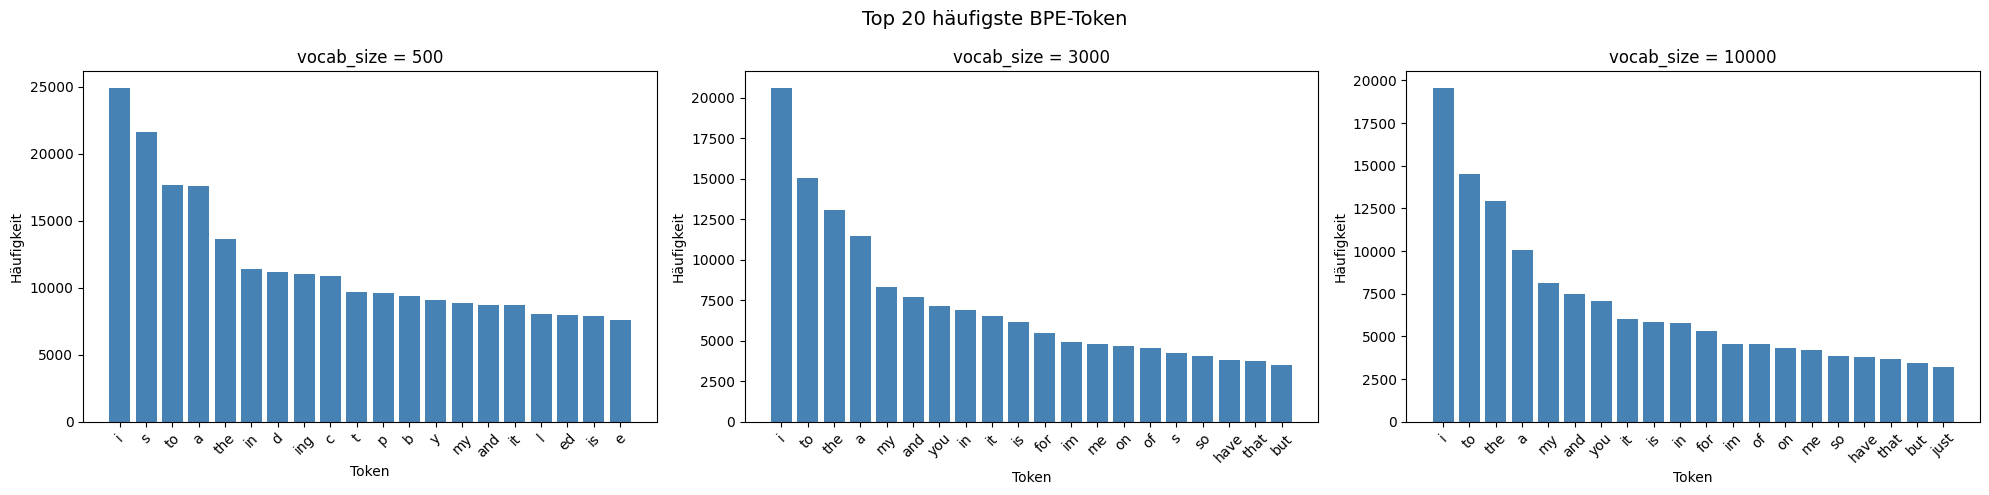

In [5]:
top_n = 20
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, (vs, tok) in zip(axes, tokenizers.items()):
    freq = get_token_counts(tok, texts).head(top_n)
    ax.bar(freq.index, freq.values, color="steelblue")
    ax.set_title(f"vocab_size = {vs}")
    ax.set_xlabel("Token")
    ax.set_ylabel("Häufigkeit")
    ax.tick_params(axis="x", rotation=45)

plt.suptitle(f"Top {top_n} häufigste BPE-Token", fontsize=14)
plt.tight_layout()
plt.savefig("../assets/barchart_bpe_tokenisierung.png", dpi=150, bbox_inches="tight")
plt.show()

## 5 Erkenntnisse

Bei einer kleinen vocab_size von 500 werden Wörter in viele kleine Teile zerlegt. Das Vokabular ist kompakt, aber ein einzelnes Wort besteht dann aus mehreren Token. Mit einer mittleren vocab_size von 3000 bleiben häufige Wörter als ganzes Token erhalten, während seltene Wörter weiterhin aufgeteilt werden. Bei einer großen vocab_size von 10000 bleiben fast alle Wörter vollständig erhalten, ähnlich wie bei der Word Tokenization, jedoch werden seltene Wörter nach wie vor in Subwords zerlegt.

BPE löst damit das Out-of-Vocabulary-Problem, da jedes unbekannte Wort in bekannte Subwords aufgeteilt werden kann.

Im Gegensatz zur Word Tokenization aus Übung 4 werden hier bewusst keine Stop Words entfernt. BPE profitiert von häufigen Wörtern wie "the", "to" oder "and", da der Algorithmus gerade aus häufigen Zeichenkombinationen seine Merges lernt. In der Praxis, zum Beispiel bei BERT oder GPT, wird BPE ebenfalls immer auf dem vollen, ungefilterten Text trainiert.